<a href="https://colab.research.google.com/github/xiaann622/Analystlab/blob/week-8/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Economic Performance: GDP per Capita Capstone
**Week 8 — Data Analytics Capstone Project | AnalystLab Africa Data Analytics Internship**

## Objective
To analyze how global economic prosperity has changed over the past several
decades, using GDP per capita as the measure, in order to answer:
- How has the world's average standard of living changed since 1990?
- Which economies are pulling ahead, and which are falling behind?
- Is there real evidence that poorer economies are catching up to richer
  ones over time (economic convergence)?

## Problem Statement
Economic development is uneven across the world, and policymakers,
investors, and development organizations need clear, data-driven answers —
not assumptions — about where growth is happening, where it's stalling, and
whether the gap between rich and poor economies is closing or widening.
This notebook uses real World Bank data across ~190 economies and 34 years
to answer that with evidence rather than anecdote.

## Data Source
World Bank **World Development Indicators (WDI)**, theme: **Economy**
(official WDI Topic name: `Economic Policy & Debt`), narrowed to the
indicator **GDP per capita, PPP (constant 2021 international $)**
(`NY.GDP.PCAP.PP.KD`).
https://databank.worldbank.org/source/world-development-indicators


In [4]:
# Install the one package Colab doesn't have by default.
# country_converter gives verified continent classifications (Stadler, 2017,
# JOSS) so we don't have to hand-type 190+ country classifications.
!pip install country_converter --quiet

In [5]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import country_converter as coco

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11})

## Step 1 — Load your data

You've already downloaded `WDI_CSV.zip` and extracted it. Upload the 3
files it contains using the Colab file browser (folder icon in the left
sidebar → upload icon), or run the cell below to use the upload picker:
- `WDICSV.csv` — the actual data (all themes, all indicators)
- `WDISeries.csv` — indicator metadata (has the `Topic` column)
- `WDICountry.csv` — country metadata (has the `Region` column)

In [6]:
REQUIRED = ["WDICSV.csv", "WDISeries.csv", "WDICountry.csv"]
missing = [f for f in REQUIRED if not os.path.exists(f)]

if missing:
    try:
        from google.colab import files
        print(f"Missing: {missing} -- opening upload picker (select all 3 files at once)")
        files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"Missing {missing}. If you're not in Colab, place these files in the "
            f"working directory manually and re-run this cell."
        )
    missing = [f for f in REQUIRED if not os.path.exists(f)]

if missing:
    raise FileNotFoundError(f"Still missing after upload: {missing}. Re-run this cell.")
else:
    print("All 3 files present:", REQUIRED)

DATA_PATH = "WDICSV.csv"
SERIES_PATH = "WDISeries.csv"
COUNTRY_PATH = "WDICountry.csv"
!ls -la *.csv

All 3 files present: ['WDICSV.csv', 'WDISeries.csv', 'WDICountry.csv']
-rw-r--r-- 1 root root    156476 Aug 31 08:12 WDICountry.csv
-rw-r--r-- 1 root root 198481686 Aug 31 08:15 WDICSV.csv
-rw-r--r-- 1 root root   5961768 Aug 31 08:12 WDISeries.csv


## Step 2 — Extract: Filter to the Economy theme

The main data file has no theme/category column — that classification
lives in `WDISeries.csv`'s `Topic` column. The official WDI Topic name for
"Economy" is **`Economic Policy & Debt`** (confirmed against the real
metadata file — it covers 510 indicators: GDP, national accounts, external
debt, balance of payments, and purchasing power parity).

In [7]:
THEME = "Economic Policy & Debt"   # the real WDI Topic name for "Economy"

series = pd.read_csv(SERIES_PATH)
economy_series = series[series["Topic"].str.startswith(THEME, na=False)]
economy_codes = set(economy_series["Series Code"])
print(f"{len(economy_codes)} indicators found under '{THEME}'")

data = pd.read_csv(DATA_PATH)
print(f"Full dataset: {data.shape[0]} rows, {data['Indicator Code'].nunique()} indicators, "
      f"{data['Country Code'].nunique()} economies")

economy_data = data[data["Indicator Code"].isin(economy_codes)]
print(f"Economy-only: {economy_data.shape[0]} rows, {economy_data['Indicator Code'].nunique()} indicators")

360 indicators found under 'Economic Policy & Debt'
Full dataset: 396970 rows, 1498 indicators, 265 economies
Economy-only: 95400 rows, 360 indicators


## Step 3 — Narrow to one indicator for the deep-dive analysis

510 economy indicators is too many to analyze meaningfully in one capstone.
This notebook focuses specifically on **GDP per capita, PPP** as the
headline measure of economic performance — a deliberate choice, not the
whole Economy theme. (Swap `INDICATOR_CODE` below to analyze a different
economy indicator instead — `WDIsearch`-style browsing of `economy_series`
above will show you what's available.)

In [8]:
INDICATOR_CODE = "NY.GDP.PCAP.PP.KD"  # GDP per capita, PPP (constant 2021 international $)

raw = economy_data[economy_data["Indicator Code"] == INDICATOR_CODE].copy()
print(f"Selected indicator: {raw['Indicator Name'].iloc[0]}")
print(f"Rows (one per economy): {raw.shape[0]}")

Selected indicator: GDP per capita, PPP (constant 2021 international $)
Rows (one per economy): 265


## Step 4 — Clean

Three real issues to fix, found by actually inspecting this data rather
than assuming it's clean:

1. **Footer rows.** The World Bank export appends a few trailing
   metadata rows with no `Country Code` — drop them.
2. **Aggregate rows disguised as countries.** The bulk file includes 47
   regional/income-group aggregates ("World", "Sub-Saharan Africa",
   "Upper middle income", ...) that carry a real-looking `Country Code`
   but aren't actual economies. Left in, "World" or "Sub-Saharan Africa"
   would show up in a top-15 ranking as if it were a country. The
   correct way to exclude them: `WDICountry.csv` has a `Region` field
   that's blank for every aggregate and filled in for every real
   economy — filter on that, not on the country name looking unusual.
3. **Missing values, and why there are so many.** This dataset runs
   1960-2025 (66 years), but PPP-adjusted GDP figures don't exist for
   most countries before 1990 — the underlying price-comparison surveys
   simply weren't conducted that far back. The result: roughly half of
   all country-year cells are missing overall, but almost entirely
   concentrated in 1960-1989 (~100% missing there) versus under 15% missing
   from 1990 onward. That's a real characteristic of the indicator, not a
   data quality problem to explain away. The code below coerces every
   value to numeric and lets pandas turn anything non-numeric — a blank
   cell, or the literal string `".."` if you're using an older WDI
   export that encodes missing values that way instead — into a proper
   NaN, so it's caught regardless of which convention the file uses.

In [9]:
raw = raw[raw["Country Code"].notna()].copy()

# Exclude World Bank aggregates (World, regions, income groups) using the
# real distinguishing signal: WDICountry.csv leaves "Region" blank for
# every aggregate and filled in for every real economy.
country_meta = pd.read_csv(COUNTRY_PATH)
real_economy_codes = set(country_meta[country_meta["Region"].notna()]["Country Code"])
aggregate_rows_found = raw[~raw["Country Code"].isin(real_economy_codes)]
if len(aggregate_rows_found):
    print(f"Excluding {len(aggregate_rows_found)} aggregate rows (not real economies): "
          f"{aggregate_rows_found['Country Name'].tolist()}")
raw = raw[raw["Country Code"].isin(real_economy_codes)]

year_cols = [c for c in raw.columns if c[:2] in ("19", "20")]
long_df = raw.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_per_capita_ppp",
)
long_df["year"] = long_df["year"].astype(int)
long_df = long_df.rename(columns={"Country Name": "country", "Country Code": "country_code"})

# Coerces to numeric -- catches blank cells, "..", or anything else non-numeric
long_df["gdp_per_capita_ppp"] = pd.to_numeric(long_df["gdp_per_capita_ppp"], errors="coerce")

missing = long_df["gdp_per_capita_ppp"].isna().sum()
print(f"Missing values: {missing} of {len(long_df)} ({missing/len(long_df)*100:.1f}%) -- "
      f"see the breakdown by decade below to confirm this is concentrated pre-1990")

decade = (long_df["year"] // 10) * 10
print(long_df.assign(decade=decade).groupby("decade")["gdp_per_capita_ppp"]
      .apply(lambda s: f"{s.isna().mean()*100:.0f}% missing"))

# Dropped, not imputed -- a fabricated economic figure would misrepresent the country
long_df = long_df.dropna(subset=["gdp_per_capita_ppp"])
long_df = long_df[long_df["gdp_per_capita_ppp"] > 0]  # sanity check: no non-positive values
long_df = long_df.drop_duplicates(subset=["country_code", "year"])

print(f"\nClean dataset: {long_df.shape[0]} country-year rows, {long_df['country_code'].nunique()} economies")

Excluding 48 aggregate rows (not real economies): ['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World', 'Caribbean small states', 'Central Europe and the Baltics', 'Early-demographic dividend', 'East Asia & Pacific', 'East Asia & Pacific (excluding high income)', 'East Asia & Pacific (IDA & IBRD countries)', 'Euro area', 'Europe & Central Asia', 'Europe & Central Asia (excluding high income)', 'Europe & Central Asia (IDA & IBRD countries)', 'European Union', 'Heavily indebted poor countries (HIPC)', 'High income', 'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only', 'IDA total', 'Late-demographic dividend', 'Latin America & Caribbean', 'Latin America & Caribbean (excluding high income)', 'Latin America & the Caribbean (IDA & IBRD countries)', 'Least developed countries: UN classification', 'Low & middle income', 'Low income', 'Lower middle income', 'Middle East, North Africa, Afghanistan & Pakistan', 'Middle East, North Africa, Afghanistan & Pakistan (excludi

## Step 5 — Enrich: continent classification + calculated columns

In [10]:
cc = coco.CountryConverter()
codes = long_df["country_code"].unique().tolist()
mapping = cc.convert(names=codes, src="ISO3", to="continent", not_found=None)
lookup = dict(zip(codes, mapping))
long_df["continent"] = long_df["country_code"].map(lookup).fillna("Other/Territory")

long_df = long_df.sort_values(["country_code", "year"]).reset_index(drop=True)
long_df["yoy_growth_pct"] = (long_df.groupby("country_code")["gdp_per_capita_ppp"].pct_change() * 100).round(2)

pivot = long_df.pivot(index="country_code", columns="year", values="gdp_per_capita_ppp")
latest_year, base_year = pivot.columns.max(), pivot.columns.max() - 10
ten_yr_growth = ((pivot[latest_year] / pivot[base_year]) - 1) * 100
long_df["growth_last_10yr_pct"] = long_df["country_code"].map(ten_yr_growth).round(2)

latest = long_df[long_df["year"] == latest_year].copy()
latest["rank_latest_year"] = latest["gdp_per_capita_ppp"].rank(ascending=False, method="min").astype(int)
long_df = long_df.merge(latest[["country_code", "rank_latest_year"]], on="country_code", how="left")

print(f"Added continent, yoy_growth_pct, growth_last_10yr_pct ({base_year}-{latest_year}), rank_latest_year")
long_df.head()

Added continent, yoy_growth_pct, growth_last_10yr_pct (2015-2025), rank_latest_year


,country,country_code,year,gdp_per_capita_ppp,continent,yoy_growth_pct,growth_last_10yr_pct,rank_latest_year
0,Aruba,ABW,1990,33146.670548,America,NaN,NaN,NaN
1,Aruba,ABW,1991,34079.230463,America,2.81,NaN,NaN
2,Aruba,ABW,1992,34458.142298,America,1.11,NaN,NaN
3,Aruba,ABW,1993,34627.743475,America,0.49,NaN,NaN
4,Aruba,ABW,1994,35580.533978,America,2.75,NaN,NaN


## Step 6 — Save the cleaned dataset

In [11]:
long_df.to_csv("wdi_gdp_per_capita_clean.csv", index=False)
print(f"Saved -> wdi_gdp_per_capita_clean.csv ({long_df.shape[0]} rows)")

Saved -> wdi_gdp_per_capita_clean.csv (6977 rows)


## Step 7 — Analyze: KPIs

In [12]:
latest_year = int(long_df["year"].max())
latest = long_df[long_df["year"] == latest_year]

world_avg = latest["gdp_per_capita_ppp"].mean()
highest = latest.loc[latest["gdp_per_capita_ppp"].idxmax()]
lowest = latest.loc[latest["gdp_per_capita_ppp"].idxmin()]
fastest = latest.loc[latest["growth_last_10yr_pct"].idxmax()]
decline = latest.loc[latest["growth_last_10yr_pct"].idxmin()]

# Convergence test: does a country's starting income level predict its
# subsequent growth rate? (economic "convergence hypothesis")
base = long_df[long_df["year"] == latest_year - 10][["country_code", "gdp_per_capita_ppp"]].rename(columns={"gdp_per_capita_ppp": "base_gdp_pc"})
merged = base.merge(latest[["country_code", "growth_last_10yr_pct"]], on="country_code").dropna()
convergence_corr = round(merged["base_gdp_pc"].corr(merged["growth_last_10yr_pct"]), 3)

kpi = {
    "latest_year": latest_year,
    "countries_covered": int(latest["country_code"].nunique()),
    "world_avg_gdp_per_capita": round(world_avg, 2),
    "highest_country": highest["country"], "highest_value": round(highest["gdp_per_capita_ppp"], 2),
    "lowest_country": lowest["country"], "lowest_value": round(lowest["gdp_per_capita_ppp"], 2),
    "fastest_growing_country": fastest["country"], "fastest_growing_pct": round(fastest["growth_last_10yr_pct"], 1),
    "steepest_decline_country": decline["country"], "steepest_decline_pct": round(decline["growth_last_10yr_pct"], 1),
    "convergence_correlation": convergence_corr,
}
print(json.dumps(kpi, indent=2))
with open("kpi_summary.json", "w") as f:
    json.dump(kpi, f, indent=2)

{
  "latest_year": 2025,
  "countries_covered": 185,
  "world_avg_gdp_per_capita": 26977.22,
  "highest_country": "Singapore",
  "highest_value": 139592.61,
  "lowest_country": "Burundi",
  "lowest_value": 1066.51,
  "fastest_growing_country": "Guyana",
  "fastest_growing_pct": 594.8,
  "steepest_decline_country": "Sudan",
  "steepest_decline_pct": -55.0,
  "convergence_correlation": -0.104
}


## Step 8 — Visualize

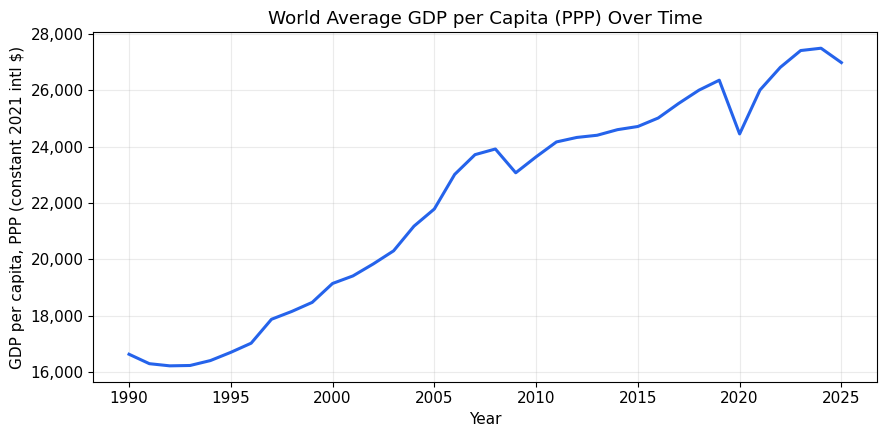

In [13]:
# Chart 1: World trend over time
trend = long_df.groupby("year")["gdp_per_capita_ppp"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(trend.index, trend.values, color="#2563eb", linewidth=2.2)
ax.set_title("World Average GDP per Capita (PPP) Over Time")
ax.set_xlabel("Year"); ax.set_ylabel("GDP per capita, PPP (constant 2021 intl $)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("chart_world_trend.png", dpi=150); plt.show()

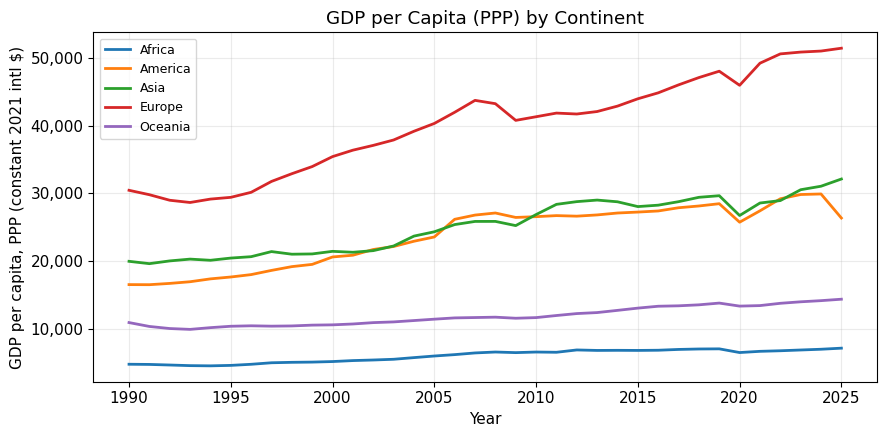

In [14]:
# Chart 2: Trend by continent
cont_trend = long_df.groupby(["year", "continent"])["gdp_per_capita_ppp"].mean().unstack()
fig, ax = plt.subplots(figsize=(9, 4.5))
for continent in cont_trend.columns:
    ax.plot(cont_trend.index, cont_trend[continent], linewidth=2, label=continent)
ax.set_title("GDP per Capita (PPP) by Continent")
ax.set_xlabel("Year"); ax.set_ylabel("GDP per capita, PPP (constant 2021 intl $)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("chart_continent_trend.png", dpi=150); plt.show()

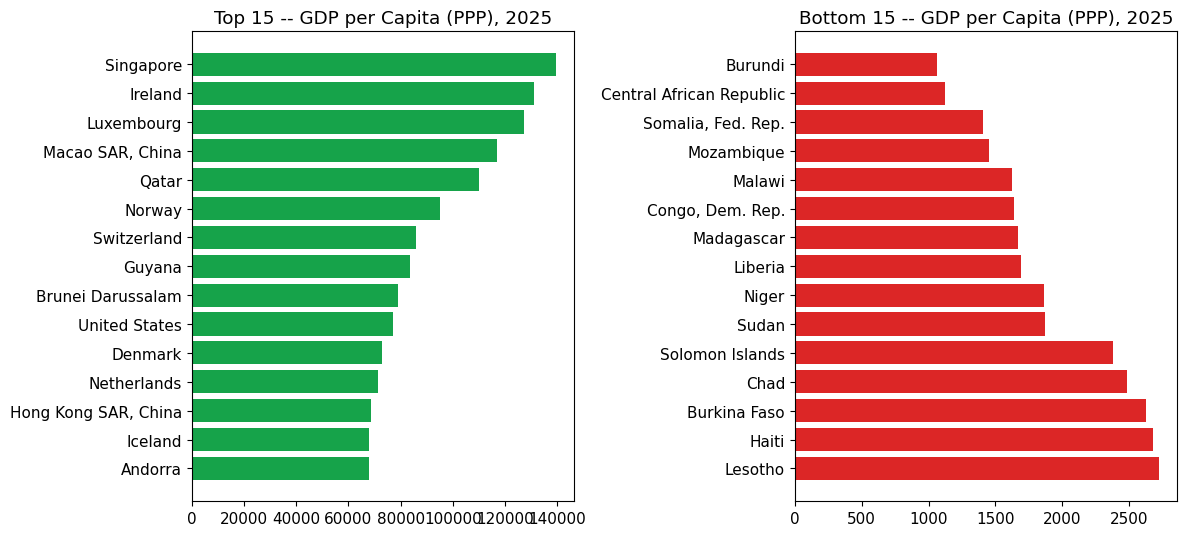

In [15]:
# Chart 3: Top and bottom 15 economies, latest year
top15 = latest.sort_values("gdp_per_capita_ppp", ascending=False).head(15)
bottom15 = latest.sort_values("gdp_per_capita_ppp", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].barh(top15["country"][::-1], top15["gdp_per_capita_ppp"][::-1], color="#16a34a")
axes[0].set_title(f"Top 15 -- GDP per Capita (PPP), {latest_year}")
axes[1].barh(bottom15["country"][::-1], bottom15["gdp_per_capita_ppp"][::-1], color="#dc2626")
axes[1].set_title(f"Bottom 15 -- GDP per Capita (PPP), {latest_year}")
plt.tight_layout(); plt.savefig("chart_top_bottom.png", dpi=150); plt.show()

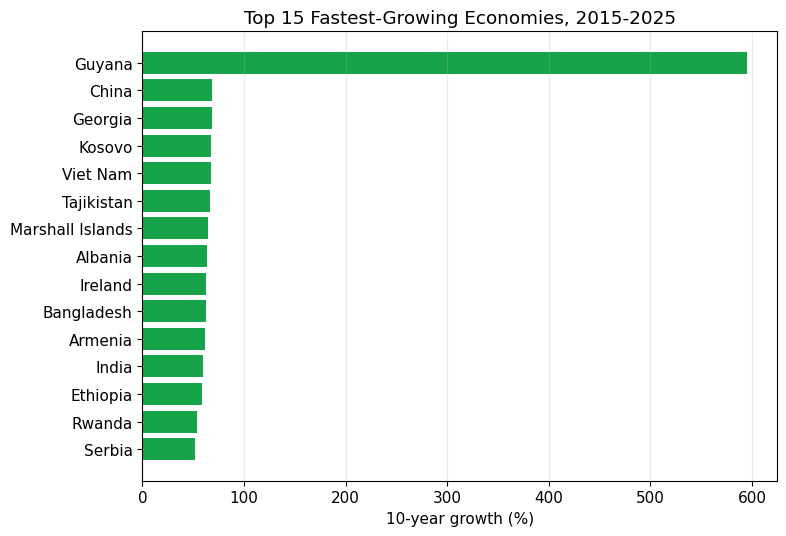

In [16]:
# Chart 4: Fastest-growing economies
fastest15 = latest.sort_values("growth_last_10yr_pct", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(fastest15["country"][::-1], fastest15["growth_last_10yr_pct"][::-1], color="#16a34a")
ax.set_title(f"Top 15 Fastest-Growing Economies, {latest_year-10}-{latest_year}")
ax.set_xlabel("10-year growth (%)")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout(); plt.savefig("chart_fastest_growing.png", dpi=150); plt.show()

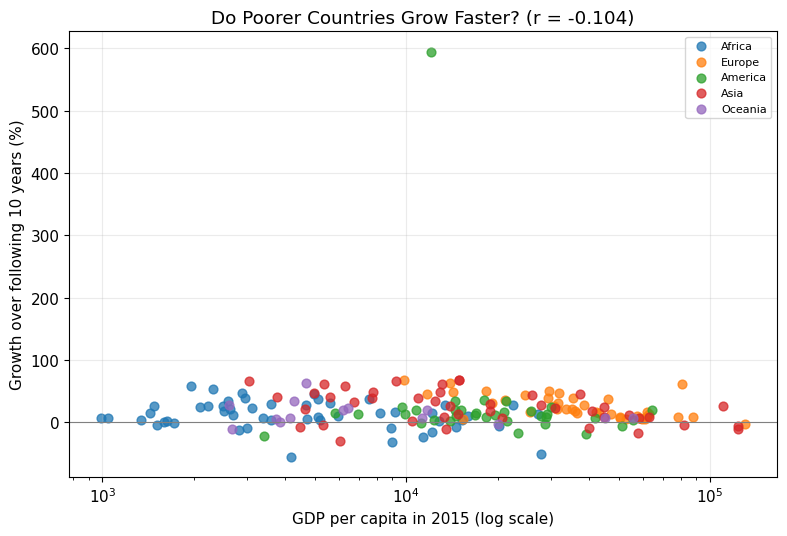

In [17]:
# Chart 5: Convergence test -- does starting income predict growth?
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_data = merged.merge(latest[["country_code", "continent"]], on="country_code")
for cont in plot_data["continent"].unique():
    subset = plot_data[plot_data["continent"] == cont]
    ax.scatter(subset["base_gdp_pc"], subset["growth_last_10yr_pct"], label=cont, alpha=0.75, s=40)
ax.set_xscale("log")
ax.set_xlabel(f"GDP per capita in {latest_year-10} (log scale)")
ax.set_ylabel("Growth over following 10 years (%)")
ax.set_title(f"Do Poorer Countries Grow Faster? (r = {convergence_corr})")
ax.axhline(0, color="grey", linewidth=0.8)
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig("chart_convergence.png", dpi=150); plt.show()

## Key Findings

Fill this in with your own printed KPI values from Step 7 before your demo
— don't read numbers from someone else's run.

- **World average GDP per capita** ({latest_year}): use `kpi['world_avg_gdp_per_capita']`
- **Highest:** `kpi['highest_country']` at `kpi['highest_value']`
- **Lowest:** `kpi['lowest_country']` at `kpi['lowest_value']`
- **Fastest growing (10yr):** `kpi['fastest_growing_country']` at `kpi['fastest_growing_pct']`%
- **Steepest decline (10yr):** `kpi['steepest_decline_country']` at `kpi['steepest_decline_pct']`%
- **Convergence correlation:** `kpi['convergence_correlation']` — weak/strong, positive/negative?

## Next Steps
- Export `wdi_gdp_per_capita_clean.csv` into Power BI for the interactive dashboard
- Assemble the final PDF report using these charts and KPIs
- Record the demo video walking through this notebook top to bottom
